# 10.5 形狀答案如何把梯度送回圖片入口？


看下面兩張合成圖：左邊是紅色方塊，右邊是藍色圓形。這次任務是回答形狀，所以人的答案先是「方塊」「圓形」。分類頭需要數字標籤，才約定方塊為 0、圓形為 1；因此兩張圖的正確標籤依序是 `[0,1]`。


In [1]:
# @title 準備本節的工具（首次執行）
from pathlib import Path
import os
import subprocess
import sys

# Colab 會先下載專案；本機 Jupyter 沿用已開啟的 repo。
try:
    import google.colab
except ImportError:
    in_colab = False
else:
    in_colab = True

if in_colab:
    root = Path("/content/tiny-perceptron-vlm")
    if not root.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "https://github.com/birdhackor/tiny-perceptron-vlm.git", str(root)],
            env={**os.environ, "GIT_LFS_SKIP_SMUDGE": "1"},
            check=True,
        )
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "-e", str(root)], check=True)
    os.chdir(root)

root = Path.cwd().resolve()
while not (root / "pyproject.toml").exists() and root != root.parent:
    root = root.parent
if not (root / "tiny_perceptron").is_dir():
    raise RuntimeError("本機請先依 course/first-steps.md 開啟 repo；免安裝練習可使用本節的 Colab 入口")
sys.path.insert(0, str(root))
import torch

torch.set_num_threads(1)
torch.manual_seed(42)

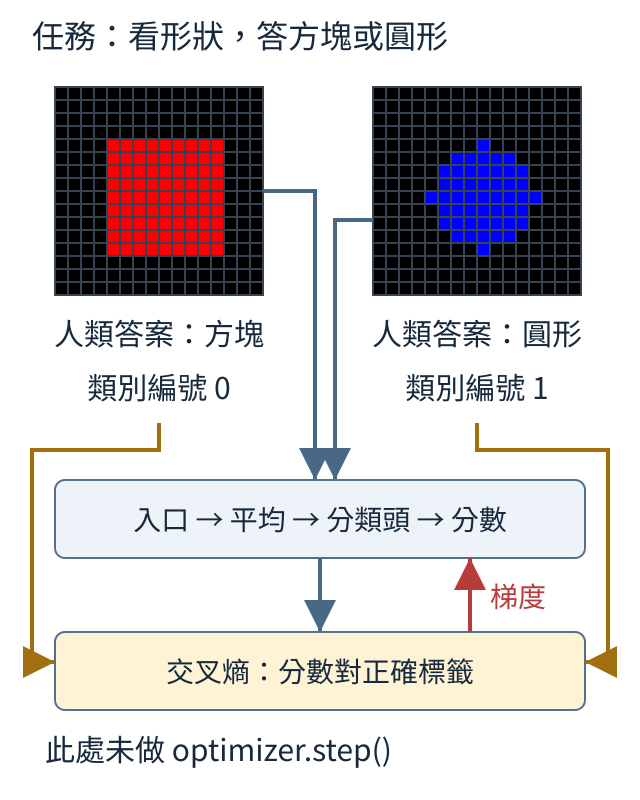

In [2]:
# @title 本節圖解
from IPython.display import SVG, display

display(SVG(filename=str(root / "course/figures/rewrite-10-shape-gradient.svg")))

編碼器把圖片變成特徵，分類頭再為方塊與圓形各算一個分數。交叉熵比較分數與正確標籤，得到猜錯代價；梯度則描述參數小幅改變會怎樣影響這個代價。本節只檢查這條影響能否傳回圖片入口。


In [3]:
import torch
from torch import nn
from torch.nn import functional as F
from tiny_perceptron.multimodal import VisionEncoder, scene

torch.manual_seed(0)
encoder = VisionEncoder(width=8)
classifier = nn.Linear(8, 2)
images = torch.stack([scene("red", "square"), scene("blue", "circle")])
features = encoder(images)
logits = classifier(features.mean(1))
loss = F.cross_entropy(logits, torch.tensor([0, 1]))
loss.backward()
print("特徵", tuple(features.shape), "分數", tuple(logits.shape))
print("入口收到梯度", encoder.projection.weight.grad.norm().item() > 0)

特徵 (2, 16, 8) 分數 (2, 2)
入口收到梯度 True


`stack` 將兩張圖放成一批。`VisionEncoder(width=8)` 產生 `(2,16,8)`：兩張圖，各 16 個位置、8 個特徵。`mean(1)` 將每張的 16 條特徵平均，再由分類頭得到 `(2,2)`，每張各有兩個候選分數。標籤來自上面的形狀規則，不是模型自己猜出的名字。

`backward()` 反向計算梯度，最後檢查入口矩陣是否收到非零梯度，預期 True。程式沒有 `optimizer.step()`，所以參數尚未更新。它展示梯度通路，而不是訓練後能辨形狀的成績。

這兩張圖還有一個資料陷阱：紅色總是方塊，藍色總是圓形。即使後續練到兩張全對，模型也可能只用顏色。若要教形狀，應讓紅圓、藍圓同標圓形，紅方、藍方同標方塊；若要教顏色，則讓同色不同形狀共享顏色標籤。目標變了，資料與判準也要一起改。

特徵如何匯整同樣取決於問題。平均可以保留部分顏色線索，卻可能失去左右排列；同一份平均表示不會自動適合所有看圖問題。分類頭先提供可核對的監督，將來接文字模型仍需另測它能否寫出完整答案。

練習把標籤改成 `[1,0]`：現在提供的是相反形狀答案。程式仍可能收到梯度，因此梯度通過不能替作者保證標籤正確。

<details>
<summary>回顧與查證</summary>

可回顧：[10.3的像素變換](https://birdhackor.github.io/tiny-perceptron-vlm/10.3.html)、[1.8分類猜錯代價](https://birdhackor.github.io/tiny-perceptron-vlm/1.8.html)、[W.6梯度](https://birdhackor.github.io/tiny-perceptron-vlm/first-steps.html#W.6)。

相關的六類「顏色＋形狀」分類實驗，其資料切分、更新設定與逐題結果見[既有實報](https://github.com/birdhackor/tiny-perceptron-vlm/blob/main/docs/course-experiments/results/encoders.json)；重做入口見[實驗說明](https://github.com/birdhackor/tiny-perceptron-vlm/blob/main/docs/course-experiments/README.md)。它用紅、綠、藍搭配方塊、圓形組成六類答案，入口特徵寬度為 16，並實際更新參數。本節則用寬度 8 示範兩類形狀標籤如何產生梯度。

</details>
